# 0. このノートブックに関して

このノートブックでは、線形モデルに対する因果探索手法NOTEARSを用いて因果探索実験を行うことを目的とする。特に、非線形モデルを因果探索する際にどの程度の精度低下が見られるのかを実験により確認する。

# 1. 線形因果グラフの場合のNOTEARS実験

## 1.1 線形モデルシミュレーションデータの生成

In [3]:
import numpy as np
from scipy.special import expit as sigmoid
import igraph as ig
import random

def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    
def is_dag(W):
    G = ig.Graph.Weighted_Adjacency(W.tolist())
    return G.is_dag()

### バイナリ隣接行列の生成

In [4]:
# バイナリ隣接行列の生成

def simulate_dag(d, s0, graph_type):
    """Simulate random DAG with some expected number of edges.

    Args:
        d (int): num of nodes
        s0 (int): expected num of edges
        graph_type (str): ER, SF, BP

    Returns:
        B (np.ndarray): [d, d] binary adj matrix of DAG
    """
    def _random_permutation(M):
        # np.random.permutation permutes first axis only
        P = np.random.permutation(np.eye(M.shape[0]))
        return P.T @ M @ P

    def _random_acyclic_orientation(B_und):
        return np.tril(_random_permutation(B_und), k=-1)

    def _graph_to_adjmat(G):
        return np.array(G.get_adjacency().data)

    if graph_type == 'ER':
        # Erdos-Renyi
        G_und = ig.Graph.Erdos_Renyi(n=d, m=s0)
        B_und = _graph_to_adjmat(G_und)
        B = _random_acyclic_orientation(B_und)
    elif graph_type == 'SF':
        # Scale-free, Barabasi-Albert
        G = ig.Graph.Barabasi(n=d, m=int(round(s0 / d)), directed=True)
        B = _graph_to_adjmat(G)
    elif graph_type == 'BP':
        # Bipartite, Sec 4.1 of (Gu, Fu, Zhou, 2018)
        top = int(0.2 * d)
        G = ig.Graph.Random_Bipartite(top, d - top, m=s0, directed=True, neimode=ig.OUT)
        B = _graph_to_adjmat(G)
    else:
        raise ValueError('unknown graph type')
    B_perm = _random_permutation(B)
    assert ig.Graph.Adjacency(B_perm.tolist()).is_dag()
    return B_perm


In [3]:
# 動作確認

B_perm_3 = simulate_dag(d=3, s0=3, graph_type='ER')
B_perm_4 = simulate_dag(d=4, s0=3, graph_type='SF')
B_perm_5 = simulate_dag(d=5, s0=4, graph_type='BP')
print(B_perm_3)
print(B_perm_4)
print(B_perm_5)


[[0. 0. 0.]
 [1. 0. 1.]
 [1. 0. 0.]]
[[0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 1. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


### 重み付き隣接行列の生成

In [5]:
def simulate_parameter(B, w_ranges=((-2.0, -0.5), (0.5, 2.0))):
    """Simulate SEM parameters for a DAG.

    Args:
        B (np.ndarray): [d, d] binary adj matrix of DAG
        w_ranges (tuple): disjoint weight ranges

    Returns:
        W (np.ndarray): [d, d] weighted adj matrix of DAG
    """
    W = np.zeros(B.shape)
    S = np.random.randint(len(w_ranges), size=B.shape)
    for i, (low, high) in enumerate(w_ranges):
        U = np.random.uniform(low=low, high=high, size=B.shape)
        W += B * (S == i) * U
    return W

In [5]:
# 動作確認

W_3 = simulate_parameter(B_perm_3)
W_4 = simulate_parameter(B_perm_4)
W_5 = simulate_parameter(B_perm_5)
print(W_3)
print(W_4)
print(W_5)

[[ 0.          0.          0.        ]
 [-0.55410455  0.          0.90170575]
 [-1.69767818  0.          0.        ]]
[[ 0.          0.         -0.62308561  0.        ]
 [ 0.          0.          0.          0.        ]
 [ 0.         -1.11774552  0.          0.        ]
 [ 0.          1.95103916  0.          0.        ]]
[[0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]
 [1.31717165 1.63184319 0.         1.27481814 1.91135393]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.        ]]


### 線形SEMの生成

In [6]:
def simulate_linear_sem(W, n, sem_type, noise_scale=None):
    """Simulate samples from linear SEM with specified type of noise.

    For uniform, noise z ~ uniform(-a, a), where a = noise_scale.

    Args:
        W (np.ndarray): [d, d] weighted adj matrix of DAG
        n (int): num of samples, n=inf mimics population risk
        sem_type (str): gauss, exp, gumbel, uniform, logistic, poisson
        noise_scale (np.ndarray): scale parameter of additive noise, default all ones

    Returns:
        X (np.ndarray): [n, d] sample matrix, [d, d] if n=inf
    """
    def _simulate_single_equation(X, w, scale):
        """X: [n, num of parents], w: [num of parents], x: [n]"""
        if sem_type == 'gauss':
            z = np.random.normal(scale=scale, size=n)
            x = X @ w + z
        elif sem_type == 'exp':
            z = np.random.exponential(scale=scale, size=n)
            x = X @ w + z
        elif sem_type == 'gumbel':
            z = np.random.gumbel(scale=scale, size=n)
            x = X @ w + z
        elif sem_type == 'uniform':
            z = np.random.uniform(low=-scale, high=scale, size=n)
            x = X @ w + z
        elif sem_type == 'logistic':
            x = np.random.binomial(1, sigmoid(X @ w)) * 1.0
        elif sem_type == 'poisson':
            x = np.random.poisson(np.exp(X @ w)) * 1.0
        else:
            raise ValueError('unknown sem type')
        return x

    d = W.shape[0]
    if noise_scale is None:
        scale_vec = np.ones(d)
    elif np.isscalar(noise_scale):
        scale_vec = noise_scale * np.ones(d)
    else:
        if len(noise_scale) != d:
            raise ValueError('noise scale must be a scalar or has length d')
        scale_vec = noise_scale
    if not is_dag(W):
        raise ValueError('W must be a DAG')
    if np.isinf(n):  # population risk for linear gauss SEM
        if sem_type == 'gauss':
            # make 1/d X'X = true cov
            X = np.sqrt(d) * np.diag(scale_vec) @ np.linalg.inv(np.eye(d) - W)
            return X
        else:
            raise ValueError('population risk not available')
    # empirical risk
    G = ig.Graph.Weighted_Adjacency(W.tolist())
    ordered_vertices = G.topological_sorting()
    assert len(ordered_vertices) == d
    X = np.zeros([n, d])
    for j in ordered_vertices:
        parents = G.neighbors(j, mode=ig.IN)
        X[:, j] = _simulate_single_equation(X[:, parents], W[parents, j], scale_vec[j])
    return X

In [7]:
# 動作確認

B_perm = simulate_dag(d=3, s0=3, graph_type='ER')
W = simulate_parameter(B_perm)
X = simulate_linear_sem(W, n=10, sem_type='gauss')

## 1.2 線形モデルに対するNOTEARSの適用

In [12]:
import numpy as np
import scipy.linalg as slin
import scipy.optimize as sopt
from scipy.special import expit as sigmoid

def notears_linear(X, lambda1, loss_type, max_iter=100, h_tol=1e-8, rho_max=1e+16, w_threshold=0.3):
    """Solve min_W L(W; X) + lambda1 ‖W‖_1 s.t. h(W) = 0 using augmented Lagrangian.

    Args:
        X (np.ndarray): [n, d] sample matrix
        lambda1 (float): l1 penalty parameter
        loss_type (str): l2, logistic, poisson
        max_iter (int): max num of dual ascent steps
        h_tol (float): exit if |h(w_est)| <= htol
        rho_max (float): exit if rho >= rho_max
        w_threshold (float): drop edge if |weight| < threshold

    Returns:
        W_est (np.ndarray): [d, d] estimated DAG
    """
    def _loss(W):
        """Evaluate value and gradient of loss."""
        M = X @ W
        if loss_type == 'l2':
            R = X - M
            loss = 0.5 / X.shape[0] * (R ** 2).sum()
            G_loss = - 1.0 / X.shape[0] * X.T @ R
        elif loss_type == 'logistic':
            loss = 1.0 / X.shape[0] * (np.logaddexp(0, M) - X * M).sum()
            G_loss = 1.0 / X.shape[0] * X.T @ (sigmoid(M) - X)
        elif loss_type == 'poisson':
            S = np.exp(M)
            loss = 1.0 / X.shape[0] * (S - X * M).sum()
            G_loss = 1.0 / X.shape[0] * X.T @ (S - X)
        else:
            raise ValueError('invalid loss type')
        return loss, G_loss
    
    def _h(W):
        """Evaluate value and gradient of acyclicity constraint."""
        E = slin.expm(W * W)
        h = np.trace(E) - d
        G_h = E.T * W * 2
        return h, G_h
        
        
    def _adj(w):
        """Convert doubled variables ([2 d^2] array) back to original variables ([d, d] matrix)."""
        return (w[:d * d] - w[d * d:]).reshape([d, d])
    
    def _func(w):
        """Evaluate value and gradient of augmented Lagrangian for doubled variables ([2 d^2] array)."""
        W = _adj(w)
        loss, G_loss = _loss(W)
        h, G_h = _h(W)
        obj = loss + 0.5 * rho * h * h + alpha * h + lambda1 * w.sum()
        G_smooth = G_loss + (rho * h + alpha) * G_h
        g_obj = np.concatenate([G_smooth + lambda1, - G_smooth + lambda1], axis=None)
        return obj, g_obj
    
    n, d = X.shape
    w_est, rho, alpha, h = np.zeros([2 * d * d]), 1.0, 0.0, np.inf
    bnds = [(0, 0) if i == j else (0, None) for _ in range(2) for i in range(d) for j in range(d)]
    if loss_type == 'l2':
        X = X - np.mean(X, axis=0, keepdims=True)
    for _ in range(max_iter):
        w_new, h_new = None, None
        while rho < rho_max:
            sol = sopt.minimize(_func, w_est, method='L-BFGS-B', jac=True, bounds=bnds)
            w_new = sol.x
            h_new, _ = _h(_adj(w_new))
            if h_new > 0.25 * h:
                rho *= 10
            else:
                break
        w_est, h = w_new, h_new
        alpha += rho * h
        if h <= h_tol or rho >= rho_max:
            break
    W_est = _adj(w_est)
    W_est[np.abs(W_est) < w_threshold] = 0
    return W_est

In [9]:
n, d, s0, graph_type, sem_type = 100, 20, 20, 'ER', 'gauss'
B_true = simulate_dag(d, s0, graph_type)
W_true = simulate_parameter(B_true)

X = simulate_linear_sem(W_true, n, sem_type)

W_est = notears_linear(X, lambda1=0.1, loss_type='l2')
assert is_dag(W_est)

In [7]:
def count_accuracy(B_true, B_est):
    """Compute various accuracy metrics for B_est.

    true positive = predicted association exists in condition in correct direction
    reverse = predicted association exists in condition in opposite direction
    false positive = predicted association does not exist in condition

    Args:
        B_true (np.ndarray): [d, d] ground truth graph, {0, 1}
        B_est (np.ndarray): [d, d] estimate, {0, 1, -1}, -1 is undirected edge in CPDAG

    Returns:
        fdr: (reverse + false positive) / prediction positive
        tpr: (true positive) / condition positive
        fpr: (reverse + false positive) / condition negative
        shd: undirected extra + undirected missing + reverse
        nnz: prediction positive
    """
    if (B_est == -1).any():  # cpdag
        if not ((B_est == 0) | (B_est == 1) | (B_est == -1)).all():
            raise ValueError('B_est should take value in {0,1,-1}')
        if ((B_est == -1) & (B_est.T == -1)).any():
            raise ValueError('undirected edge should only appear once')
    else:  # dag
        if not ((B_est == 0) | (B_est == 1)).all():
            raise ValueError('B_est should take value in {0,1}')
        if not is_dag(B_est):
            raise ValueError('B_est should be a DAG')
    d = B_true.shape[0]
    # linear index of nonzeros
    pred_und = np.flatnonzero(B_est == -1)
    pred = np.flatnonzero(B_est == 1)
    cond = np.flatnonzero(B_true)
    cond_reversed = np.flatnonzero(B_true.T)
    cond_skeleton = np.concatenate([cond, cond_reversed])
    # true pos
    true_pos = np.intersect1d(pred, cond, assume_unique=True)
    # treat undirected edge favorably
    true_pos_und = np.intersect1d(pred_und, cond_skeleton, assume_unique=True)
    true_pos = np.concatenate([true_pos, true_pos_und])
    # false pos
    false_pos = np.setdiff1d(pred, cond_skeleton, assume_unique=True)
    false_pos_und = np.setdiff1d(pred_und, cond_skeleton, assume_unique=True)
    false_pos = np.concatenate([false_pos, false_pos_und])
    # reverse
    extra = np.setdiff1d(pred, cond, assume_unique=True)
    reverse = np.intersect1d(extra, cond_reversed, assume_unique=True)
    # compute ratio
    pred_size = len(pred) + len(pred_und)
    cond_neg_size = 0.5 * d * (d - 1) - len(cond)
    fdr = float(len(reverse) + len(false_pos)) / max(pred_size, 1)
    tpr = float(len(true_pos)) / max(len(cond), 1)
    fpr = float(len(reverse) + len(false_pos)) / max(cond_neg_size, 1)
    # structural hamming distance
    pred_lower = np.flatnonzero(np.tril(B_est + B_est.T))
    cond_lower = np.flatnonzero(np.tril(B_true + B_true.T))
    extra_lower = np.setdiff1d(pred_lower, cond_lower, assume_unique=True)
    missing_lower = np.setdiff1d(cond_lower, pred_lower, assume_unique=True)
    shd = len(extra_lower) + len(missing_lower) + len(reverse)
    return {'fdr': fdr, 'tpr': tpr, 'fpr': fpr, 'shd': shd, 'nnz': pred_size}

In [11]:
acc = count_accuracy(B_true, W_est != 0)
print(acc)

{'fdr': 0.0, 'tpr': 1.0, 'fpr': 0.0, 'shd': 0, 'nnz': 20}


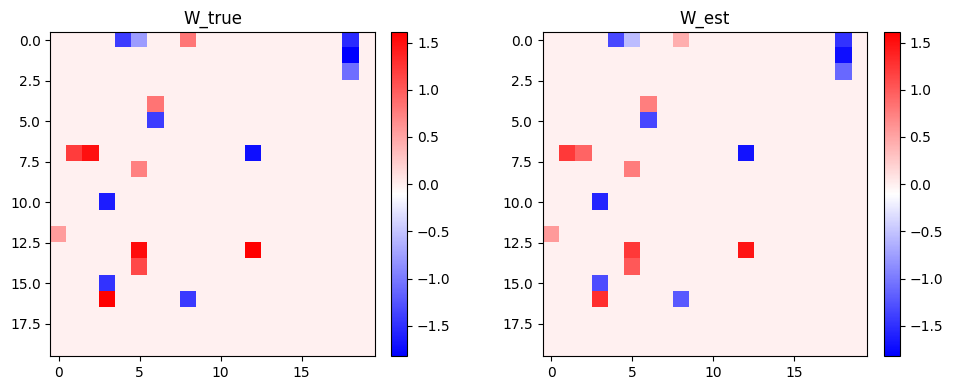

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(W_true, cmap='bwr', vmin=np.min(W_true), vmax=np.max(W_true))
axes[0].set_title('W_true')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(W_est, cmap='bwr', vmin=np.min(W_true), vmax=np.max(W_true))
axes[1].set_title('W_est')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# 2 非線形モデルに対してNOTEARSを適用する実験

## 2.1 非線形モデルのシミュレーションデータ生成

In [8]:
# 非線形モデルのシミュレーションデータ生成

def simulate_nonlinear_sem(W, gamma, n, sem_type, noise_scale=None):
    """Simulate samples from non-linear SEM with specified type of noise.

    For uniform, noise z ~ uniform(-a, a), where a = noise_scale.

    Args:
        W (np.ndarray): [d, d] weighted adj matrix of DAG
        gamma (np.ndarray): [d] nonlinearity parameter
        n (int): num of samples, n=inf mimics population risk
        sem_type (str): tanh
        noise_scale (np.ndarray): scale parameter of additive noise, default all ones

    Returns:
        X (np.ndarray): [n, d] sample matrix, [d, d] if n=inf
    """
    def _simulate_single_equation(X, gam, w, scale):
        """X: [n, num of parents], gam: float, w: [num of parents], x: [n]"""
        if sem_type == 'tanh':
            z = np.random.normal(scale=scale, size=n)
            x = gam * np.tanh(X @ w) + z
        else:
            raise ValueError(f'SEM type {sem_type} not supported')
        return x
            
    d = W.shape[0]
    if noise_scale is None:
        scale_vec = np.ones(d)
    elif np.isscalar(noise_scale):
        scale_vec = noise_scale * np.ones(d)
    else:
        if len(noise_scale) != d:
            raise ValueError('noise scale must be a scalar or has length d')
        scale_vec = noise_scale
    
    if not is_dag(W):
        raise ValueError('W must be a DAG')
    
    G = ig.Graph.Weighted_Adjacency(W.tolist())
    ordered_vertices = G.topological_sorting()
    assert len(ordered_vertices) == d
    X = np.zeros([n, d])
    for j in ordered_vertices:
        parents = G.neighbors(j, mode=ig.IN)
        X[:, j] = _simulate_single_equation(X[:, parents], gamma[j], W[parents, j], scale_vec[j])
    return X

In [9]:
# 非線形モデル（tanh）の場合の真の重み付き隣接行列の計算 W_true = diag(gamma) @ W

def true_W(gamma, W):
    return np.diag(gamma) @ W

In [39]:
n, d, s0, graph_type, sem_type = 100, 2, 1, 'ER', 'tanh'
gamma = np.array([3.0, 3.0])
B_true = simulate_dag(d, s0, graph_type)
W = simulate_parameter(B_true)
W_true = true_W(gamma, W)

X = simulate_nonlinear_sem(W, gamma, n, sem_type, noise_scale=0.1)

#W_est = notears_linear(X, lambda1=0.1, loss_type='l2')
#assert is_dag(W_est)

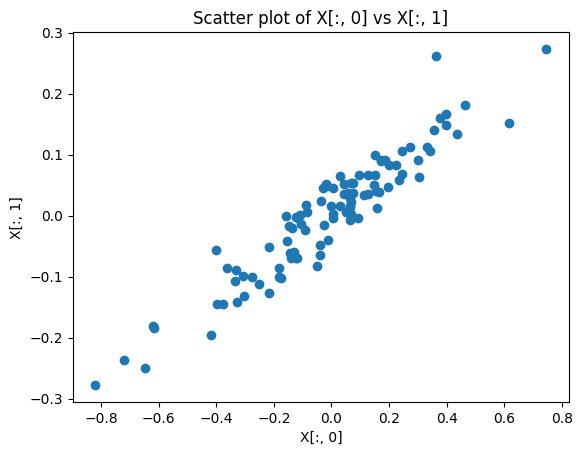

In [40]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.xlabel('X[:, 0]')
plt.ylabel('X[:, 1]')
plt.title('Scatter plot of X[:, 0] vs X[:, 1]')
plt.show()


In [21]:
n, d, s0, graph_type, sem_type = 100, 20, 20, 'ER', 'tanh'
gamma = np.ones(d) * 5.0
B_true = simulate_dag(d, s0, graph_type)
W = simulate_parameter(B_true)
W_true = true_W(gamma, W)

X = simulate_nonlinear_sem(W, gamma, n, sem_type)

W_est = notears_linear(X, lambda1=0.1, loss_type='l2', w_threshold=0.3)
assert is_dag(W_est)

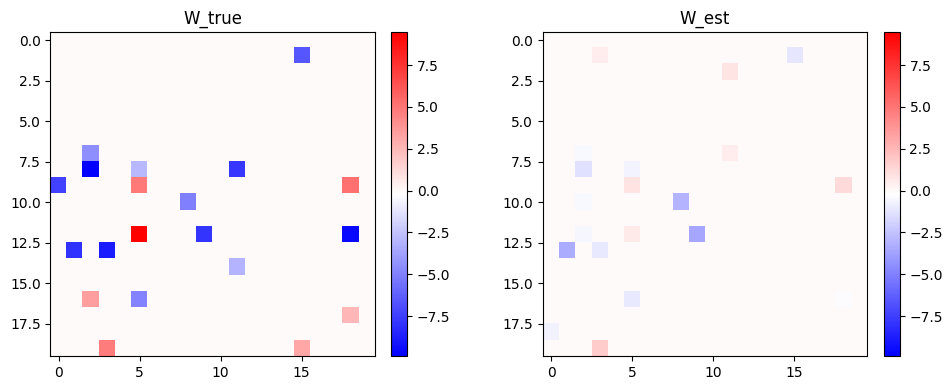

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im0 = axes[0].imshow(W_true, cmap='bwr', vmin=np.min(W_true), vmax=np.max(W_true))
axes[0].set_title('W_true')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(W_est, cmap='bwr', vmin=np.min(W_true), vmax=np.max(W_true))
axes[1].set_title('W_est')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [23]:
acc = count_accuracy(B_true, W_est != 0)
print(acc)

{'fdr': 0.35, 'tpr': 0.65, 'fpr': 0.041176470588235294, 'shd': 14, 'nnz': 20}


# 3. モジュール化の動作確認

In [4]:
from notears.linear import notears_linear
from notears.utils import is_dag, simulate_dag, simulate_parameter, simulate_nonlinear_sem, tanh_sem_jacobian
import numpy as np


n, d, s0, graph_type, sem_type = 100, 20, 20, 'ER', 'tanh'
gamma = np.ones(d) * 5.0
B_true = simulate_dag(d, s0, graph_type)
W = simulate_parameter(B_true)
W_true = tanh_sem_jacobian(gamma, W)

X = simulate_nonlinear_sem(W, gamma, n, sem_type)

W_est = notears_linear(X, lambda1=0.1, loss_type='l2', w_threshold=0.2)
assert is_dag(W_est)

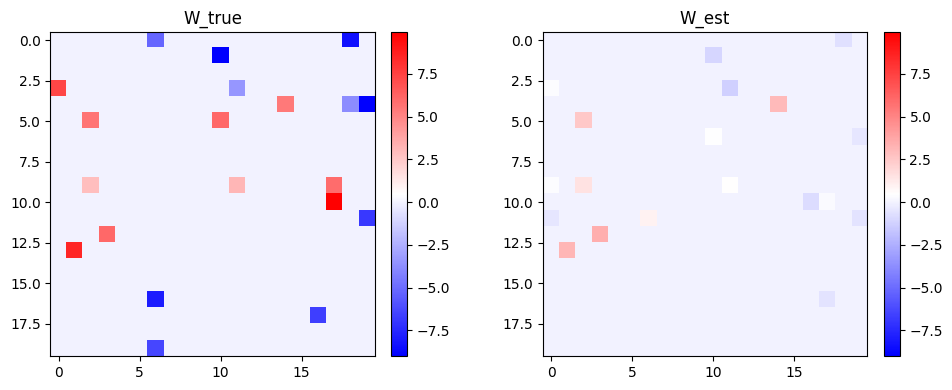

In [5]:
from notears.utils import plot_weight_matrix

plot_weight_matrix(W_true, W_est)